In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns



In [3]:
# Load directly from seaborn
df = sns.load_dataset('mpg')

# Columns: mpg, horsepower, weight, acceleration, etc.
# Simple: mpg ~ weight

In [ ]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [6]:
df.corr(numeric_only=True)
corr_matrix = df.corr(numeric_only=True)


In [11]:
for col in corr_matrix.columns:
    for idx in corr_matrix.index:
        if col != idx:
            val = corr_matrix.loc[idx,col]
            if (val ) >=0.3:
                print(f"{idx} vs {col}: {val:.2f}")
            


acceleration vs mpg: 0.42
model_year vs mpg: 0.58
displacement vs cylinders: 0.95
horsepower vs cylinders: 0.84
weight vs cylinders: 0.90
cylinders vs displacement: 0.95
horsepower vs displacement: 0.90
weight vs displacement: 0.93
cylinders vs horsepower: 0.84
displacement vs horsepower: 0.90
weight vs horsepower: 0.86
cylinders vs weight: 0.90
displacement vs weight: 0.93
horsepower vs weight: 0.86
mpg vs acceleration: 0.42
mpg vs model_year: 0.58


 * displacement vs cylinders: 0.95
 * horsepower vs cylinders: 0.84
 * displacement vs cylinders: 0.95
 * weight vs cylinders: 0.90
 * cylinders vs displacement: 0.95
 * horsepower vs displacement: 0.90
 * weight vs displacement: 0.93
 * displacement vs horsepower: 0.90
 * cylinders vs weight: 0.90
 * displacement vs weight: 0.93



Text(0.5, 0, 'cylinders')

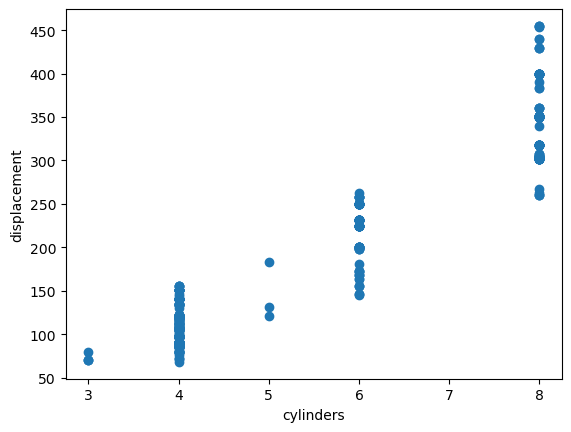

In [14]:
plt.scatter(df['cylinders'],df['displacement'])
plt.ylabel('displacement')
plt.xlabel('cylinders')

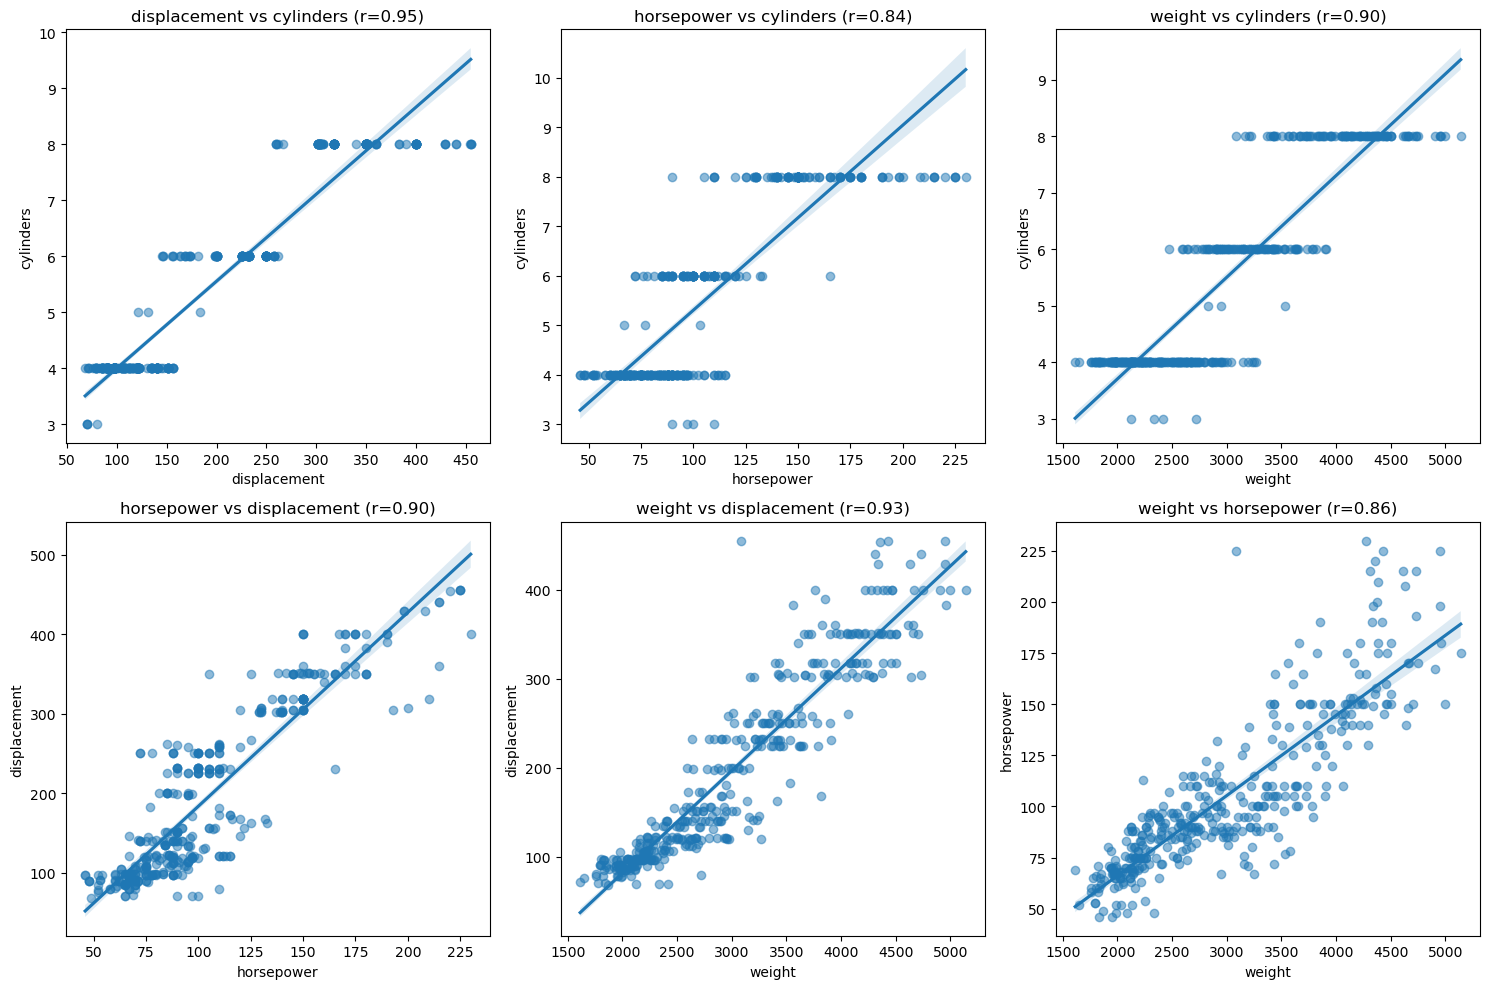

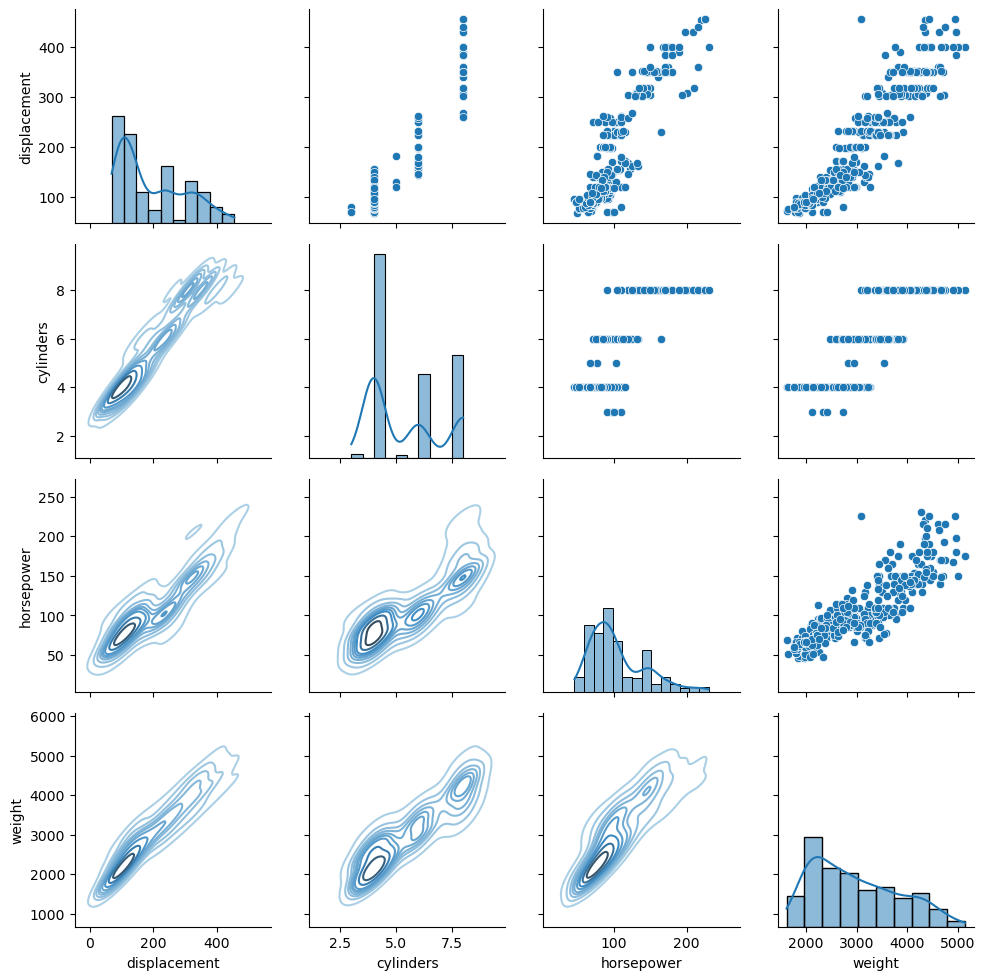

In [15]:
# Create pair plots for high correlation pairs
high_corr_pairs = [
    ('displacement', 'cylinders'),
    ('horsepower', 'cylinders'),
    ('weight', 'cylinders'),
    ('horsepower', 'displacement'),
    ('weight', 'displacement'),
    ('weight', 'horsepower')
]

# Method 1: Individual scatter plots with regression line
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, (x, y) in enumerate(high_corr_pairs):
    sns.regplot(data=df, x=x, y=y, ax=axes[i], scatter_kws={'alpha':0.5})
    axes[i].set_title(f'{x} vs {y} (r={df[x].corr(df[y]):.2f})')

plt.tight_layout()
plt.show()

# Method 2: PairGrid for selected columns only
g = sns.PairGrid(df[['displacement', 'cylinders', 'horsepower', 'weight']])
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot, cmap='Blues_d')
g.map_diag(sns.histplot, kde=True)
plt.show()

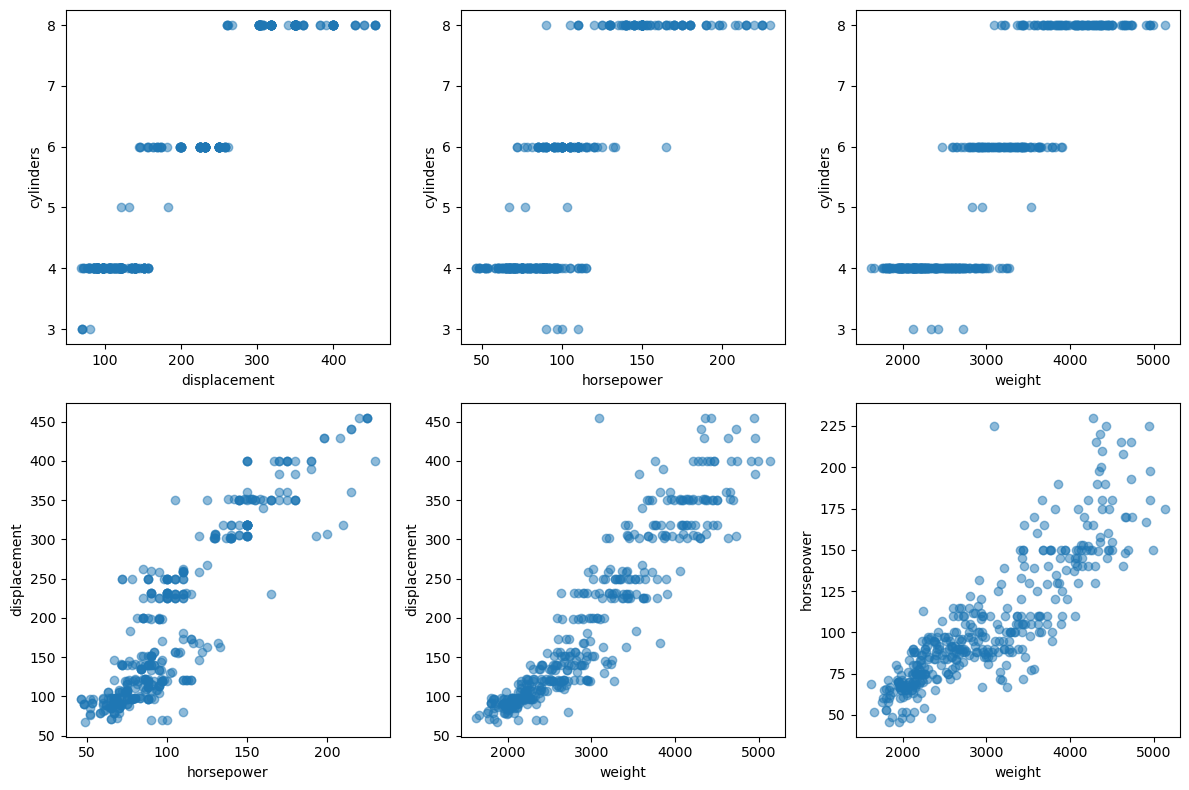

In [16]:
# Simple scatter plots for each high correlation pair
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.scatter(df['displacement'], df['cylinders'], alpha=0.5)
plt.xlabel('displacement'); plt.ylabel('cylinders')

plt.subplot(2, 3, 2)
plt.scatter(df['horsepower'], df['cylinders'], alpha=0.5)
plt.xlabel('horsepower'); plt.ylabel('cylinders')

plt.subplot(2, 3, 3)
plt.scatter(df['weight'], df['cylinders'], alpha=0.5)
plt.xlabel('weight'); plt.ylabel('cylinders')

plt.subplot(2, 3, 4)
plt.scatter(df['horsepower'], df['displacement'], alpha=0.5)
plt.xlabel('horsepower'); plt.ylabel('displacement')

plt.subplot(2, 3, 5)
plt.scatter(df['weight'], df['displacement'], alpha=0.5)
plt.xlabel('weight'); plt.ylabel('displacement')

plt.subplot(2, 3, 6)
plt.scatter(df['weight'], df['horsepower'], alpha=0.5)
plt.xlabel('weight'); plt.ylabel('horsepower')

plt.tight_layout()
plt.show()

In [46]:
# Check for NaN
print(df.iloc[:,3:4].isna().sum())

# Fix options:
# 1. Drop NaN
df_clean = df.dropna(subset=[df.columns[3], df.columns[4]])
X = df_clean.iloc[:,4:5]  
y = df_clean.iloc[:,3:4]

# 2. Fill NaN  
df[df.columns[3]] = df[df.columns[3]].fillna(df[df.columns[3]].median())
X = df.iloc[:,4:5]  
y = df.iloc[:,3:4]

horsepower    6
dtype: int64


In [47]:
for idx, col in enumerate(df.columns):
    print(f"{idx}: {col}")

0: mpg
1: cylinders
2: displacement
3: horsepower
4: weight
5: acceleration
6: model_year
7: origin
8: name


#  horsepower vs  weight


In [48]:
X = df.iloc[:,4:5]  
y = df.iloc[:,3:4]

In [39]:
X

,weight
0,3504
1,3693
2,3436
3,3433
4,3449
...,...
393,2790
394,2130
395,2295
396,2625


In [49]:
y

,horsepower
0,130.0
1,165.0
2,150.0
3,150.0
4,140.0
...,...
393,86.0
394,52.0
395,84.0
396,79.0


In [50]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [51]:
from sklearn.linear_model import LinearRegression

In [52]:
lr = LinearRegression()

In [53]:
lr.fit(X_train,y_train)

LinearRegression()

In [54]:
X_test


,weight
94,4735
32,2046
279,2135
178,2957
354,2320
...,...
298,3900
222,4060
65,4129
261,3410


In [55]:
y_test

,horsepower
94,215.0
32,93.5
279,68.0
178,88.0
354,93.5
...,...
298,125.0
222,110.0
65,153.0
261,120.0


# Step-by-step:

X_test.iloc[0] → first row of test set (single sample)

.values → converts from DataFrame to numpy array

.reshape(1,1) → reshapes to 2D array with 1 row, 1 column

# Why reshape?

Model was trained on 2D data (samples × features)

Single sample needs shape (1,1) not (1,) or scalar

In [56]:
lr.predict(X_test.iloc[0].values.reshape(1,1))

c:\Users\manis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[172.83724023]])

#  horsepower vs  weight

Text(0, 0.5, 'weight')

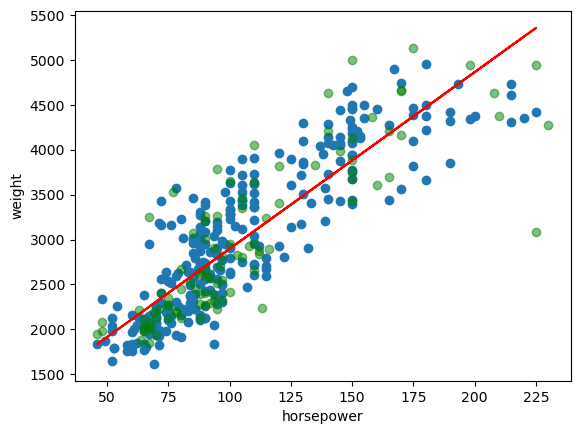

In [58]:
# Your X is horsepower, y is weight
X = df[['horsepower']]  # 2D
y = df['weight']

X_train, X_test, y_train, y_test = train_test_split(X, y)
lr.fit(X_train, y_train)

# Plot
plt.scatter(X_train, y_train)  # actual
plt.scatter(X_test, y_test, color='green', alpha=0.5)  # optional test
plt.plot(X_train, lr.predict(X_train), color='red')  # X_train is horsepower values
plt.xlabel('horsepower')
plt.ylabel('weight')